<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/06_QSAR_%E1%84%92%E1%85%AA%E1%86%AF%E1%84%89%E1%85%A5%E1%86%BC%E1%84%8B%E1%85%A8%E1%84%8E%E1%85%B3%E1%86%A8_ChEMBL__chembl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 06 · QSAR: ChEMBL 데이터로 약물 활성 예측
### "이 분자가 표적 단백질에 얼마나 잘 붙을까?"


신약개발의 핵심은 **표적 단백질에 강하게 결합(=활성)** 하는 분자를 찾는 것입니다.
활성은 보통 **IC50**(농도가 낮을수록 강력)로 측정합니다.
합성·측정 전에 **구조로 활성을 예측(QSAR)** 하면, 수만 개 후보 중 유망한 것만 골라
실험 비용을 획기적으로 줄일 수 있습니다.

**이 노트북은 실제 데이터를 씁니다**: **ChEMBL** 은 전 세계 표준 생체활성 데이터베이스입니다.
여기서는 **BACE-1**(알츠하이머 표적) 저해제 데이터를 사용합니다.


In [ ]:
!pip install rdkit -q
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen

# 실제 BACE-1 저해제 데이터 (MoleculeNet 공개, ChEMBL 기반, 1513개 분자)
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv"
df = pd.read_csv(url)
print("분자 수:", len(df))
# pIC50 = -log10(IC50): 값이 클수록 강력한 저해제
print(df[["mol","pIC50","Class"]].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 38.1 MB/s eta 0:00:00
분자 수: 1513
                                                 mol     pIC50  Class
0  O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...  9.154901      1
1  Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...  8.853872      1
2  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...  8.698970      1
3  S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...  8.698970      1
4  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...  8.698970      1


## 1. pIC50 이란?
- IC50: 활성을 절반으로 억제하는 농도 (작을수록 강력)
- **pIC50 = -log10(IC50 in M)**: 다루기 쉽게 로그 변환 (**클수록 강력**)
- pIC50 7 = IC50 100nM (강함), pIC50 5 = IC50 10µM (약함)

목표: **구조(SMILES) → pIC50 예측**


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,836 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


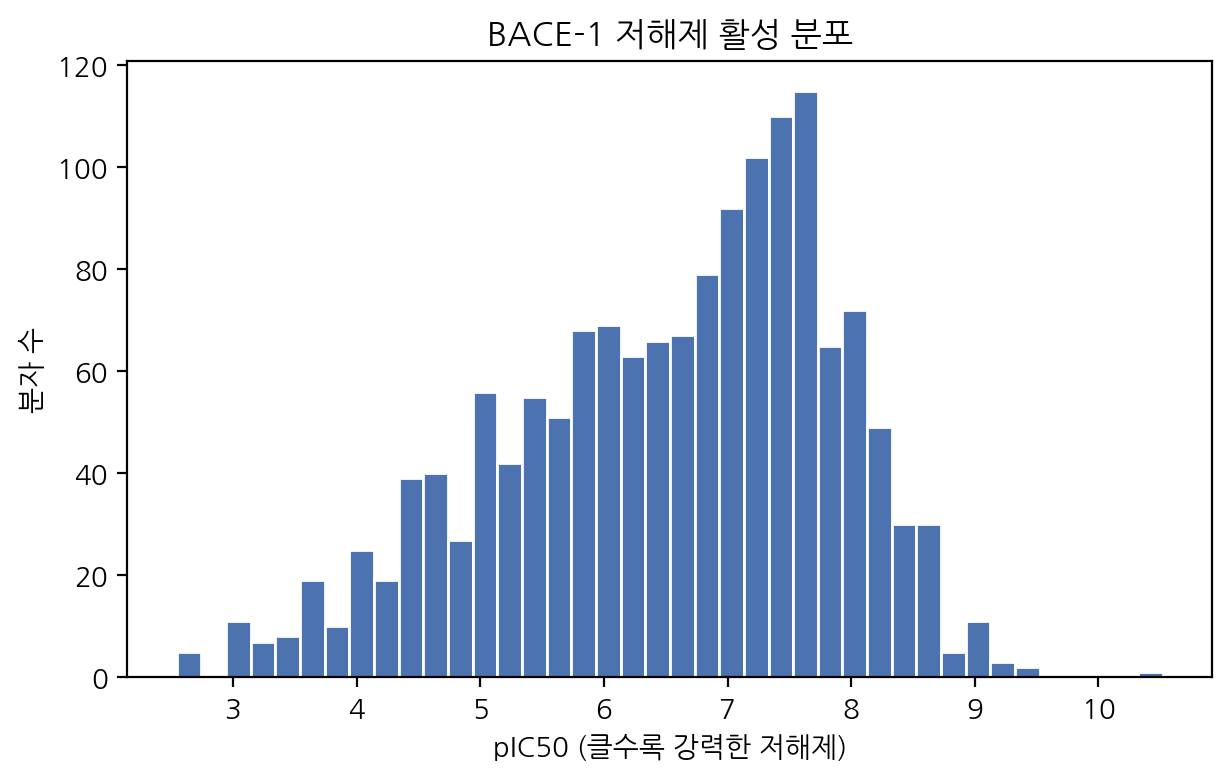

In [ ]:
# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf') #정규분포의 모양을 따를수록 예측이 쉬워지기 때문에 로그를 씌우는것
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

plt.figure(figsize=(7,4))
plt.hist(df["pIC50"], bins=40, color="#4C72B0", edgecolor="white")
plt.xlabel("pIC50 (클수록 강력한 저해제)"); plt.ylabel("분자 수")
plt.title("BACE-1 저해제 활성 분포"); plt.show()

## 2. 특성: Morgan 지문 + 물리화학 descriptor
QSAR 에서 가장 강력한 특성은 **Morgan 지문(ECFP:Extended-Connectivity Fingerprint)** 입니다.
여기에 분자량·LogP 등 물성을 더해 예측력을 높입니다.


In [ ]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

# 최신 RDKit 방식: MorganGenerator 설정 (1024비트 유지) # 머신러닝 하면 2차원 테이블구조를 떠올릴것
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def features(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None: return None

    # Morgan 지문 생성 및 Numpy 배열 변환
    fp = morgan_gen.GetFingerprint(m)
    arr = np.zeros(1024)
    DataStructs.ConvertToNumpyArray(fp, arr)

    # 추가 물성 6종
    extra = [Descriptors.MolWt(m), Crippen.MolLogP(m), Descriptors.TPSA(m),
             Descriptors.NumHDonors(m), Descriptors.NumHAcceptors(m),
             Descriptors.NumRotatableBonds(m)]
    return np.concatenate([arr, extra])

# 전체 데이터에 대해 특성 추출
X = np.vstack([features(s) for s in df["mol"]])
y = df["pIC50"].values
print("특성 행렬:", X.shape, "(분자 수 × 특성 수)")

특성 행렬: (1513, 1030) (분자 수 × 특성 수)


## 3. QSAR 회귀 모델 학습 & 평가


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold # 훈련 데이터와 검증데이터는 보통 80:20으로 나누어서 씀. 다 훈련 데이터로 쓰면 예측력이 떨어짐
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42).fit(Xtr,ytr)
pred = model.predict(Xte)
print("QSAR 예측 R²  :", round(r2_score(yte,pred),3))
print("QSAR 예측 MAE :", round(mean_absolute_error(yte,pred),3), "pIC50 단위")

# KFold를 사용하여 데이터를 섞도록 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(model, X, y, cv=kf, scoring="r2")
print("5겹 교차검증 R² (Shuffle 적용):", round(cv.mean(),3), "±", round(cv.std(),3))

QSAR 예측 R²  : 0.714
QSAR 예측 MAE : 0.525 pIC50 단위
5겹 교차검증 R² (Shuffle 적용): 0.714 ± 0.044


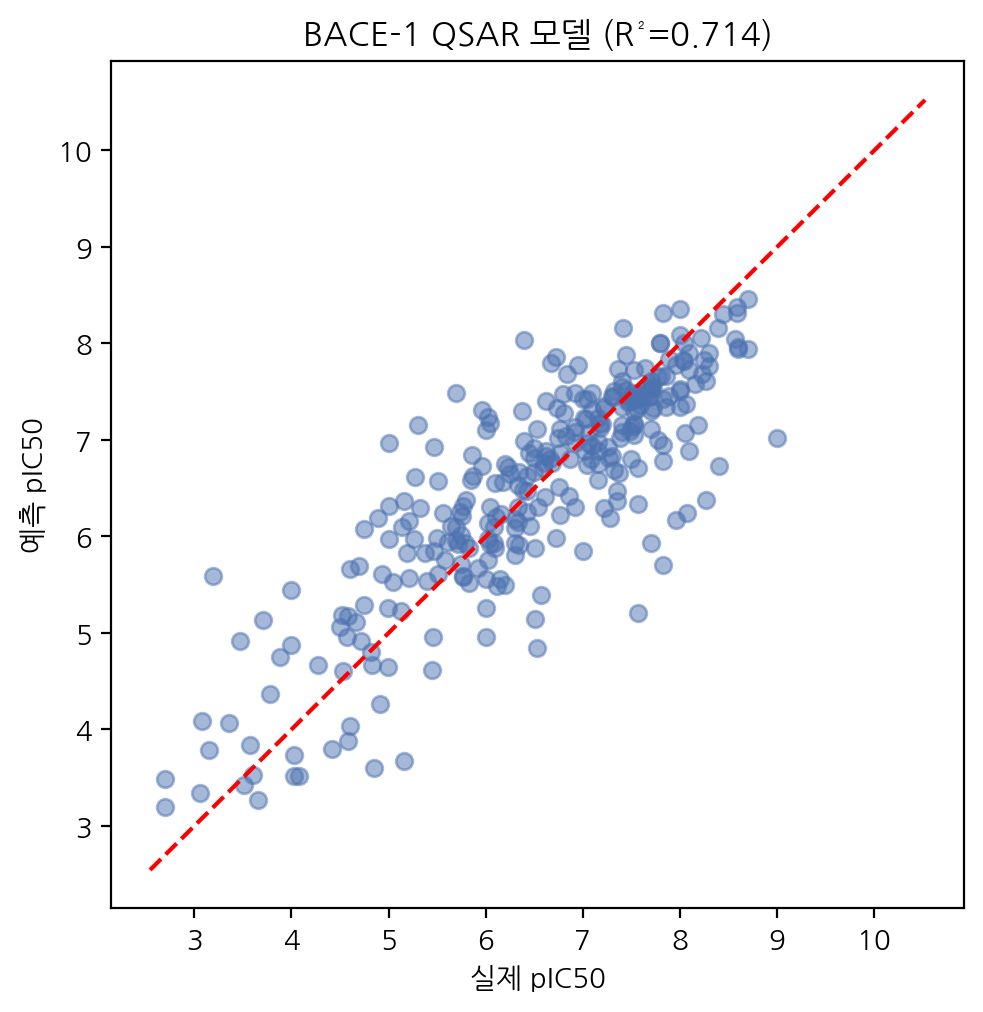

In [ ]:
# 예측 vs 실제 (대각선에 가까울수록 좋음)
plt.figure(figsize=(5.5,5.5))
plt.scatter(yte, pred, alpha=0.5, color="#4C72B0")
lim=[y.min(),y.max()]; plt.plot(lim,lim,"r--")
plt.xlabel("실제 pIC50"); plt.ylabel("예측 pIC50")
plt.title(f"BACE-1 QSAR 모델 (R²={r2_score(yte,pred):.3f})"); plt.show()

## 4. ⭐ 활용: 가상 라이브러리에서 유망 분자 우선순위
학습된 QSAR 모델로 **새 분자들의 활성을 예측**해, 합성 우선순위를 매깁니다.
이것이 실제 신약 스크리닝에서 QSAR 를 쓰는 방식입니다.


In [ ]:
# 평가셋에서 '가장 강력할 것으로 예측된' 분자 top 10
res = pd.DataFrame({"SMILES": [df['mol'].iloc[0]]*0})  # placeholder
te_idx = np.arange(len(yte))
out = pd.DataFrame({"예측pIC50": pred, "실제pIC50": yte}).sort_values("예측pIC50", ascending=False)
print("모델이 가장 강력하다고 예측한 분자 top 10:")
print(out.head(10).round(2).to_string(index=False))
print("\n→ 실제 신약개발에선 이 상위 분자들을 우선 합성·검증")

모델이 가장 강력하다고 예측한 분자 top 10:
 예측pIC50  실제pIC50
    8.46     8.70
    8.38     8.59
    8.35     8.00
    8.32     7.82
    8.31     8.59
    8.31     8.44
    8.16     7.41
    8.16     8.39
    8.09     8.00
    8.06     8.21

→ 실제 신약개발에선 이 상위 분자들을 우선 합성·검증


## 5. 분류 버전 — 활성/비활성 (Class 열)
"강력한가?(Yes/No)" 로 바꾸면 스크리닝 필터로 바로 활용 가능합니다.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
yc = df["Class"].values   # 1=활성, 0=비활성
Xtr,Xte,ytr,yte = train_test_split(X,yc,test_size=0.2,random_state=42,stratify=yc)
clf = RandomForestClassifier(n_estimators=400,n_jobs=-1,random_state=42).fit(Xtr,ytr)
proba = clf.predict_proba(Xte)[:,1]
print(classification_report(yte, clf.predict(Xte), target_names=["비활성","활성"]))
print("ROC-AUC:", round(roc_auc_score(yte,proba),3))

              precision    recall  f1-score   support

         비활성       0.81      0.81      0.81       165
          활성       0.77      0.78      0.77       138

    accuracy                           0.79       303
   macro avg       0.79      0.79      0.79       303
weighted avg       0.79      0.79      0.79       303

ROC-AUC: 0.882


## 정리 & 현장 응용
- **실제 ChEMBL 데이터**로 QSAR 모델 구축 → 구조만으로 활성(pIC50) 예측
- Morgan 지문 + 물성 특성이 강력, 교차검증으로 신뢰도 확인
- 예측 활성으로 **후보물질 우선순위** → 실험 비용 대폭 절감
- 다른 표적으로 확장: ChEMBL 웹에서 표적별 데이터 다운로드 후 `mol`/`pIC50` 열만 맞추면 재사용
